# Lens Picture

This notebook demonstrates the simulation and optimization of an optical system using the `diffinytrace` package.  
It was run in **Google Colab** to take advantage of GPU acceleration and Google Drive integration for saving results.


In [1]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=88812 sha256=5666754bd81285164d374136a957cc67b7b9e85c51b4c1397a29a71648d504e1
  Stored in directory: /tmp/pip-ephem-wheel-cache-kw4re0m9/wheels/db/ea/21/35eb070bb05c3b3e3b9b47ff193267b4ac5b0871240da78a7c
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Mounted at /content/gdrive


num of conv points should probably be at least  336.0


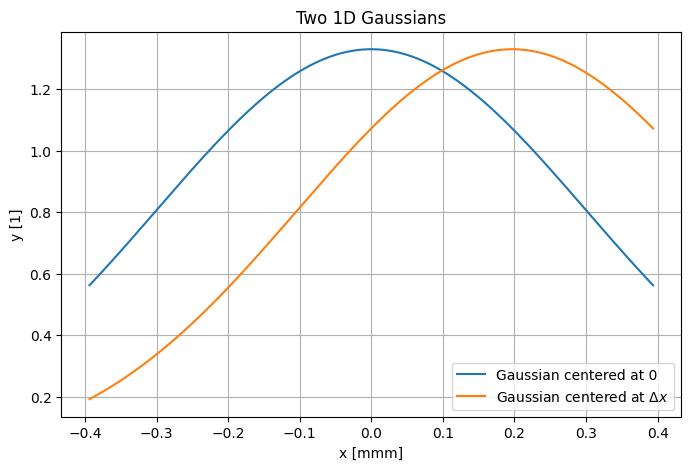

In [3]:
import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


from sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/lens_picture/"
create_folder(results_folder_main)
sigma_final = 0.3
#theta_max_rad=5.

sigmas = None
ns_start = [4,4]
orders = [3,3]
num_refinements = 6
#num_refinements = 4
lens_thickness:float=5.

theta_max_rad = 20/1000.
detector_distance:float=60.

lens_distance:float=5.0

aperture_radius_source = 21.
image_padding = 0.2
grid_size = 256
num_rays = 2**21
#[1601,1601]
from diffinytrace import utils
#from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)

import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/grid_size
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=r'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()

gc.collect()
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

#quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_desired_irradiance_smoothing,T_margin):
    create_folder(subfolder_main)
    subfolder = subfolder_main

    #create_folder(subfolder)
    kwargs = dict(image_file_name=image_file_name,
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["AIR"],
                device=device,
                sigma=sigma_final,
                use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,
                num_rays=num_rays,
                num_refinements=num_refinements,
                grid_size=grid_size,
                theta_max_rad=theta_max_rad,
                T_margin=T_margin,
                lens_thickness=lens_thickness,
                detector_distance=detector_distance,
                lens_distance=lens_distance,
                )

    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()



In [4]:
from diffinytrace import (
    source, transforms, Bspline, Plane, Lens, Detector, SequentialOpticalSystem,
    utils, plotting, target_grid, render, minimize, set_unused_bspline_coeff_to_nearest,
    export, gaussian_smoother
)
import matplotlib.pyplot as plt
import diffinytrace as dit
import torch
from typing import List



aperture_radius_source:float=21.
aperture_radius_lens:float=25.
image_padding:float=0.2


lens_material=dit.materials["PMMA"]
air_material=dit.materials["AIR"]
light_transform = transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_transform.pos.requires_grad = False

light_source = None

light_source = source.VisibleSunlightSimpleMonochromatic(light_transform,aperture_radius_source,wl=0.5,total_power=1.0,theta_max_rad=theta_max_rad)
lens_transform = transforms.Distance(lens_distance,parent_transform=light_transform)

aperture_radius_detector = aperture_radius_source*(1+image_padding)

bspline_surface1 = Bspline(aperture_radius_lens,orders,ns_start)

surface1 = Plane()
lens1 = Lens(lens_transform,lens_thickness,surface1,bspline_surface1,lens_material,aperture_radius_lens,is_square=True)
lens_transform.distance.requires_grad = False
lens1.lens_thickness.requires_grad = False
detector_transform = transforms.Distance(detector_distance,parent_transform=lens1)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = Plane()
detector = Detector(detector_transform,plane_surface,aperture_radius_detector)
system = SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},air_material)
sequence = ["source","lens","detector"]


x,weights = light_source.sample([1,5,5,5],"simpson")

#x,weights = light_source.sample(2000)

O,D,wave_len,_,RayPaths = system(x,sequence)

system.to("cpu")
offset_arrows = -(aperture_radius_lens+1)


Only sobol_pow2,sobol or monte_carlo sampling supported for VisibleSunlightSimpleMonochromatic


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [14]:

def run_all_methods():

    gc.collect()

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True,T_margin=None)

    gc.collect()
    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_desired_irradiance_smoothing = False,T_margin=None)


    gc.collect()


run_all_methods()

in create lens
after system init
after system to device
pre smoother init
after smoother init
after eval_func init
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0071, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00705260743574
last_error (tensor(0.0082), tensor(0.0002), tensor(0.7922)) 0.008244025422616102
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0064, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00641845394323
last_error (tensor(0.0077), tensor(0.0002), tensor(0.8056)) 0.00765247376305787
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0046, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00464712997668
last_error (tensor(0.0062), tensor(0.0001), tensor(0.8206)) 0.006184337578308565
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0031, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0031097300493
last_error (tensor(0.0050), tensor(9.9376e-05), tensor(0

100%|██████████| 1000/1000 [12:15<00:00,  1.36it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_desired_irr_smoothing/results_dict.pkl
in create lens
after system init
after system to device
pre smoother init
after smoother init
after eval_func init
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0087, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00869124639883
last_error (tensor(0.0087), tensor(0.0002), tensor(0.7489)) 0.008648570836628374
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0078, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00784546959036
last_error (tensor(0.0078), tensor(0.0002), tensor(0.7961)) 0.007776924767509648
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0063, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00628575566533
last_error (tensor(0.0063), tensor(0.0001), tensor(0.8058)) 0.006265553724726324
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0051, device='c

100%|██████████| 1000/1000 [12:15<00:00,  1.36it/s]


Data saved to gdrive/MyDrive/results_final/lens_picture//results_classical/results_dict.pkl


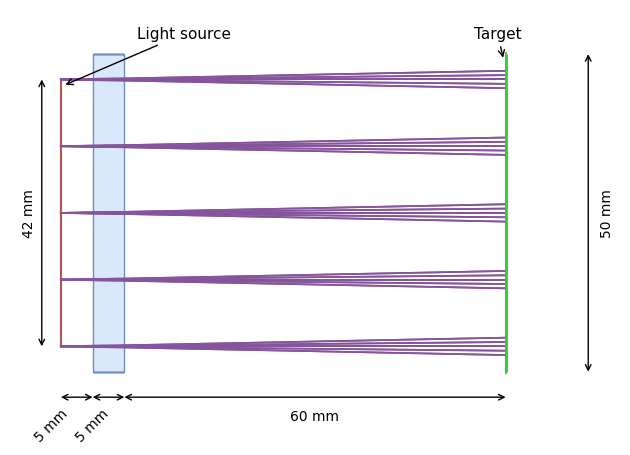

In [6]:

dit.plotting.system2D.plot(system,RayPaths,500,show = False)
"""dit.plotting.system2D.annotated_arrow([0,offset_arrows],[lens_distance,offset_arrows],(-30,-12),f"${int(lens_distance)}$[mm]","<->")
dit.plotting.system2D.annotated_arrow([lens_distance,offset_arrows],[lens_distance+lens_thickness,offset_arrows],(-12,-12),f"${int(lens_thickness)}$[mm]","<->")
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness,offset_arrows],[lens_distance+lens_thickness+detector_distance,offset_arrows],(0,-12),f"${int(detector_distance)}$[mm]","<->")

dit.plotting.system2D.annotated_arrow([-1,-aperture_radius_source],[-1,aperture_radius_source],(-12,-12),f"${int(aperture_radius_source*2)}$[mm]","<->",rotation=90)
dit.plotting.system2D.annotated_arrow([lens_distance+lens_thickness+detector_distance+1,-aperture_radius_detector],[lens_distance+lens_thickness+detector_distance+1,aperture_radius_detector],(3,-12),f"${int(aperture_radius_detector*2)}$[mm]","<->",rotation=90)

dit.plotting.system2D.annotate_position([0,aperture_radius_source],(-20,20),"Light source")
dit.plotting.system2D.annotate_position([lens_distance+lens_thickness,aperture_radius_lens],(15,10),"Lens")
dit.plotting.system2D.annotate_position([lens_distance+lens_thickness+detector_distance,aperture_radius_detector],(-50,10),"Target")
"""
ax = plt.gca()
z_source = 0.0
z_lens_start = 5.0
z_lens_end = 10.0
z_target = 70.0

source_half_height = 21.0   # 42 mm total
lens_half_height = 25.0     # 50 mm total (covers full aperture)
target_half_height = 25.0   # 50 mm total

# Target (green vertical line)
ax.plot([z_target, z_target], [-target_half_height, target_half_height],
        color='limegreen', linewidth=2.0, solid_capstyle='butt')

# --- Annotations ---

# "Light source" label with arrow
ax.annotate('Light source', xy=(z_source + 0.3, source_half_height - 1),
            xytext=(12, 27), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
            ha='left', va='bottom')

# "Target" label with arrow
ax.annotate('Target', xy=(z_target - 0.3, target_half_height - 1),
            xytext=(65, 27), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.0),
            ha='left', va='bottom')

# --- Dimension arrows ---
from matplotlib.patches import FancyArrowPatch

def dim_arrow(ax, x0, y0, x1, y1):
    """Draw a double-headed dimension arrow with tips exactly at endpoints."""
    arrow = FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle='<->', mutation_scale=10,
        color='black', lw=1.0, shrinkA=0, shrinkB=0, clip_on=False)
    ax.add_patch(arrow)

# Vertical dimension: 42 mm on left side (close to source)
dim_x_left = -3.0
dim_arrow(ax, dim_x_left, -source_half_height, dim_x_left, source_half_height)
ax.text(dim_x_left - 2.0, 0, '42 mm', fontsize=10, ha='center', va='center',
        rotation=90)

# Vertical dimension: 50 mm on right side (close to target)
dim_x_right = 83.0
dim_arrow(ax, dim_x_right, -target_half_height, dim_x_right, target_half_height)
ax.text(dim_x_right + 3.0, 0, '50 mm', fontsize=10, ha='center', va='center',
        rotation=90)

# Horizontal dimensions at bottom
dim_y = -29.0

# 5 mm: z=0 to z=5
dim_arrow(ax, z_source, dim_y, z_lens_start, dim_y)
ax.text((z_source + z_lens_start) / 2 - 4.0, dim_y - 1.5, '5 mm', fontsize=10,
        ha='center', va='top', rotation=45)

# 5 mm: z=5 to z=10
dim_arrow(ax, z_lens_start, dim_y, z_lens_end, dim_y)
ax.text((z_lens_start + z_lens_end) / 2 - 2.5, dim_y - 1.5, '5 mm', fontsize=10,
        ha='center', va='top', rotation=45)

# 70 mm: z=10 to z=80
dim_arrow(ax, z_lens_end, dim_y, z_target, dim_y)
ax.text((z_lens_end + z_target) / 2, dim_y - 2.0, '60 mm', fontsize=10,
        ha='center', va='top')

# --- Remove frame, axis labels, tick labels ---
ax.set_axis_off()

# Set limits to give appropriate padding
ax.set_xlim(-8, 88)
ax.set_ylim(-34, 32)
ax.set_aspect('equal')

plt.tight_layout()

plt.savefig(path+"/layout3.png", dpi=400, bbox_inches='tight')

#import os
#os.kill(os.getpid(), 9)